# Unidad 3 · Preparación de variables para modelamiento

**Qué vas a aprender**
- La diferencia entre rendimientos **simples** y **logarítmicos**, y cuándo usar cada uno.
- Transformar series de precios: escala logarítmica, base 100, estandarización, anualización.
- Construir variables derivadas: medias móviles, volatilidad, RSI, caída desde el máximo, rezagos.
- La regla de oro: **ninguna variable puede usar información del futuro**.
- Dejar un conjunto de datos listo para los modelos, con su variable objetivo.

**Qué tiene que ver con la app.** El piloto entero descansa en dos variables derivadas: la
**volatilidad prevista** (una media exponencial de los rendimientos al cuadrado) y la **caída desde el
máximo** de los últimos 180 días. Al final del cuaderno las calculas tú y ves qué recomendaría.

In [1]:
#@title Preparación: ejecuta esta celda primero (▶). Carga los precios de Binance.
# Es la misma en todos los cuadernos. Cómo se construye se explica en la Unidad 1.
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})

ACTIVOS = ["BTC", "ETH", "SOL"]        # las monedas de la cartera de ejemplo del piloto
COLORES = {"BTC": "#F7931A", "ETH": "#627EEA", "SOL": "#9945FF"}
DESDE = "2020-01-01"                    # el piloto también mira desde 2020
HASTA = "2026-09-26"                    # fija las cifras del texto; None = hasta ayer
ANUAL = 365                             # las criptos cotizan todos los días del año
API = "https://data-api.binance.vision/api/v3/klines"   # api.binance.com bloquea Colab


def descargar(simbolo, desde=DESDE):
    """Velas diarias YA CERRADAS de SIMBOLO/USDT en Binance, 1000 por petición."""
    inicio = int(pd.Timestamp(desde, tz="UTC").timestamp() * 1000)
    filas = []
    while True:
        r = requests.get(API, params={"symbol": f"{simbolo}USDT", "interval": "1d",
                                      "startTime": inicio, "limit": 1000}, timeout=30)
        r.raise_for_status()
        lote = r.json()
        filas += lote
        if len(lote) < 1000:
            break
        inicio = lote[-1][0] + 1                      # la página siguiente empieza tras la última vela
    crudo = pd.DataFrame([f[:7] for f in filas],
                         columns=["apertura_ms", "open", "high", "low", "close", "volume", "cierre_ms"])
    crudo = crudo[crudo["cierre_ms"] < pd.Timestamp.now(tz="UTC").timestamp() * 1000]
    df = pd.DataFrame({"fecha": pd.to_datetime(crudo["apertura_ms"], unit="ms", utc=True)})
    for c in ["open", "high", "low", "close", "volume"]:
        df[c] = crudo[c].astype(float).to_numpy()
    return df.drop_duplicates("fecha").reset_index(drop=True)


def velas(simbolo):
    """Velas diarias del periodo de estudio: del CSV si ya está, si no de Binance (y lo guarda)."""
    archivo = f"{simbolo}USDT_1d.csv"
    hoy = pd.Timestamp.now(tz="UTC").normalize()
    fin = pd.Timestamp(HASTA, tz="UTC") if HASTA else hoy - pd.Timedelta(days=1)
    df = None
    if os.path.exists(archivo):
        df = pd.read_csv(archivo)
        df["fecha"] = pd.to_datetime(df["fecha"], utc=True)
    if df is None or df["fecha"].max() < fin:
        try:
            df = descargar(simbolo)
            df.to_csv(archivo, index=False, date_format="%Y-%m-%dT%H:%M:%SZ")
        except requests.RequestException as e:
            if df is None:
                raise RuntimeError(f"No pude descargar {simbolo} de Binance ({e}). Sube {archivo} "
                                   "(carpeta de datos de respaldo del curso) y repite.") from None
            print(f"Aviso: sin conexión con Binance; {archivo} llega solo al {df['fecha'].max():%d-%m-%Y}.")
    df = df[(df["fecha"] >= pd.Timestamp(DESDE, tz="UTC")) & (df["fecha"] <= fin)]
    return df.set_index("fecha")


def cierres(activos=ACTIVOS):
    """Cierres diarios, una columna por moneda: la tabla con la que trabaja el piloto."""
    return pd.DataFrame({a: velas(a)["close"] for a in activos})


print(f"Listo. Periodo de estudio: del {DESDE} al {HASTA or 'día de ayer'}.")

Listo. Periodo de estudio: del 2020-01-01 al 2026-09-26.


## 1. Rendimientos simples y logarítmicos

| | Fórmula | Se suma bien… |
|---|---|---|
| **simple** | $r_t = P_t / P_{t-1} - 1$ | **entre activos**: el rendimiento de una cartera es la media ponderada de los simples |
| **logarítmico** | $\ell_t = \ln(P_t / P_{t-1})$ | **en el tiempo**: el de un año es la suma de los de cada día |

Para movimientos pequeños casi coinciden; para movimientos grandes, no.

In [2]:
btc = velas("BTC")
p = btc["close"]
simple = p.pct_change()
logr = np.log(p).diff()
tabla = pd.DataFrame({"simple": simple, "log": logr}).dropna()
print(tabla.loc[pd.to_datetime(["2020-03-12", "2020-03-13", "2023-01-02"], utc=True)].map("{:+.2%}".format))

                            simple      log
2020-03-12 00:00:00+00:00  -39.50%  -50.26%
2020-03-13 00:00:00+00:00  +16.22%  +15.03%
2023-01-02 00:00:00+00:00   +0.34%   +0.34%


El 12-03-2020 BTC cayó un 39,5 % (simple), que en logarítmico es un −50,3 %. Al día siguiente rebotó un
16,2 % (15,0 % en logarítmico). Un día normal, como el 02-01-2023, los dos dan +0,34 %: con movimientos
de pocos puntos la diferencia es despreciable.

### Propiedad 1: los logarítmicos se suman en el tiempo

In [3]:
total_log = logr.sum()
print(f"Suma de los rendimientos log diarios: {total_log:.4f}")
print(f"ln(precio final / precio inicial):    {np.log(p.iloc[-1] / p.iloc[0]):.4f}")
print(f"Suma de los simples (¡mal!):          {simple.sum():.4f}  ->  real: {p.iloc[-1] / p.iloc[0] - 1:.4f}")

Suma de los rendimientos log diarios: 2.4618
ln(precio final / precio inicial):    2.4618
Suma de los simples (¡mal!):          3.7116  ->  real: 10.7254


Sumar rendimientos simples no da el rendimiento total: hay que **multiplicar** `(1 + r)`. Con los
logarítmicos basta sumar, y por eso son los que se usan para medir la volatilidad a lo largo del
tiempo y en casi todos los modelos estadísticos.

Ojo con la asimetría de los simples: subir un 50 % y luego bajar un 50 % **no** te deja igual.

In [4]:
print("+50 % y −50 % en simple:", 1.5 * 0.5 - 1)
print("En log:", np.log(1.5) + np.log(0.5), "= ln(0.75) =", np.log(0.75))

+50 % y −50 % en simple: -0.25
En log: -0.2876820724517809 = ln(0.75) = -0.2876820724517809


### Propiedad 2: los simples se promedian entre activos

Un día cualquiera, con la cartera de ejemplo del piloto (0,05 BTC, 1,2 ETH y 10 SOL): el cambio de
valor de la cartera es **exactamente** la media de los rendimientos simples ponderada por lo que pesa
cada moneda ese día. Con logarítmicos es solo una aproximación.

In [5]:
precios = cierres().dropna()
unidades = pd.Series({"BTC": 0.05, "ETH": 1.2, "SOL": 10.0})
valor = precios * unidades                          # dinero en cada moneda, cada día
dia = "2022-11-09"                                  # la quiebra de FTX
ayer = valor.index[valor.index.get_loc(dia) - 1]
pesos = valor.loc[ayer] / valor.loc[ayer].sum()
real = valor.loc[dia].sum() / valor.loc[ayer].sum() - 1
r_s = precios.loc[dia] / precios.loc[ayer] - 1
r_l = np.log(precios.loc[dia] / precios.loc[ayer])
print(f"Cambio real del valor:        {real:+.4%}")
print(f"Σ peso × simple:              {(pesos * r_s).sum():+.4%}   (exacto)")
print(f"Σ peso × log, pasado a simple: {np.expm1((pesos * r_l).sum()):+.4%}   (aproximado)")

Cambio real del valor:        -18.4886%
Σ peso × simple:              -18.4886%   (exacto)
Σ peso × log, pasado a simple: -18.9097%   (aproximado)


El piloto usa cada uno donde corresponde: mide la volatilidad con logarítmicos y calcula el rendimiento
de tu mezcla de monedas pasando a simples, `np.expm1(log) @ pesos` (`expm1(x)` es `eˣ − 1`).

## 2. Transformaciones de la serie

- **Escala logarítmica** del precio: la misma distancia vertical es el mismo porcentaje.
- **Base 100**: dividir por el primer valor y multiplicar por 100, para comparar series (Unidad 1).
- **Estandarizar**: restar la media y dividir por la desviación típica. Así una variable mide "cuántas
  desviaciones se aleja de lo normal". Cuidado: con la media de **toda** la muestra, cada día "conoce"
  el futuro. Hay que usar una media **móvil** del pasado.
- **Anualizar**: la volatilidad diaria por $\sqrt{365}$ (las criptos cotizan todos los días; en bolsa se
  usa 252).

In [6]:
z_todo = (logr - logr.mean()) / logr.std()                                   # usa el futuro
z_movil = (logr - logr.rolling(365).mean()) / logr.rolling(365).std()       # solo el pasado
print("Volatilidad diaria:", round(logr.std(), 4), "| anual:", round(logr.std() * np.sqrt(ANUAL), 3))
print("Días a más de 4 desviaciones (toda la muestra):", int((z_todo.abs() > 4).sum()),
      "| una normal esperaría", round(2 * 3.167e-5 * logr.count(), 2))

Volatilidad diaria: 0.0321 | anual: 0.613
Días a más de 4 desviaciones (toda la muestra): 11 | una normal esperaría 0.16


## 3. Variables derivadas

Una tabla de variables construidas solo con datos **hasta el día t**:

| Variable | Qué mide |
|---|---|
| `r`, `r_1`, `r_2` | rendimiento log de hoy, de ayer y de anteayer (**rezagos**) |
| `dist_sma50` | cuánto está el precio por encima de su media de 50 días |
| `mom_30` | rendimiento de los últimos 30 días (*momentum*) |
| `vol_30` | volatilidad anual de los últimos 30 días |
| `vol_ewma` | volatilidad anual con media exponencial, λ = 0,94: **la del piloto** |
| `rsi_14` | índice de fuerza relativa de 14 días (0 a 100) |
| `caida_180` | caída desde el máximo de los últimos 180 días: **el freno del piloto** |
| `vol_rel` | volumen de hoy frente a su media de 30 días |

**La media exponencial** (EWMA) da a cada día un peso que decrece: hoy pesa $1-\lambda$ = 6 %, ayer
$6\% \times 0{,}94$, anteayer $6\% \times 0{,}94^2$... Reacciona rápido a un sobresalto y lo va olvidando.
Su fórmula es una línea: $\sigma^2_t = \lambda\,\sigma^2_{t-1} + (1-\lambda)\,r_t^2$.

In [7]:
def ewm(x, alpha):
    """Media exponencial: y_t = alpha * x_t + (1 - alpha) * y_{t-1}, empezando en el primer dato."""
    return x.ewm(alpha=alpha, adjust=False).mean()


d = pd.DataFrame({"close": p, "volume": btc["volume"]})
d["r"] = np.log(d["close"]).diff()
d["r_1"] = d["r"].shift(1)
d["r_2"] = d["r"].shift(2)
d["dist_sma50"] = d["close"] / d["close"].rolling(50).mean() - 1
d["mom_30"] = np.log(d["close"]).diff(30)
d["vol_30"] = d["r"].rolling(30).std() * np.sqrt(ANUAL)
d["vol_ewma"] = np.sqrt(ewm(d["r"] ** 2, 1 - 0.94) * ANUAL)
cambio = d["close"].diff()
subidas, bajadas = ewm(cambio.clip(lower=0), 1 / 14), ewm(-cambio.clip(upper=0), 1 / 14)
d["rsi_14"] = 100 - 100 / (1 + subidas / bajadas)
d["caida_180"] = d["close"] / d["close"].rolling(180, min_periods=1).max() - 1
d["vol_rel"] = d["volume"] / d["volume"].rolling(30).mean()
d.drop(columns=["close", "volume"]).tail().round(3)

,r,r_1,r_2,dist_sma50,mom_30,vol_30,vol_ewma,rsi_14,caida_180,vol_rel
fecha,,,,,,,,,,
2026-09-22 00:00:00+00:00,-0.005,0.065,-0.001,0.163,0.103,0.425,0.494,72.283,-0.005,1.342
2026-09-23 00:00:00+00:00,-0.021,-0.005,0.065,0.132,0.066,0.430,0.489,65.491,-0.026,1.417
2026-09-24 00:00:00+00:00,0.000,-0.021,-0.005,0.126,0.072,0.430,0.474,65.515,-0.026,1.212
2026-09-25 00:00:00+00:00,-0.004,0.000,-0.021,0.116,0.062,0.430,0.460,64.316,-0.029,1.162
2026-09-26 00:00:00+00:00,0.004,-0.004,0.000,0.115,0.051,0.427,0.446,65.056,-0.025,0.528


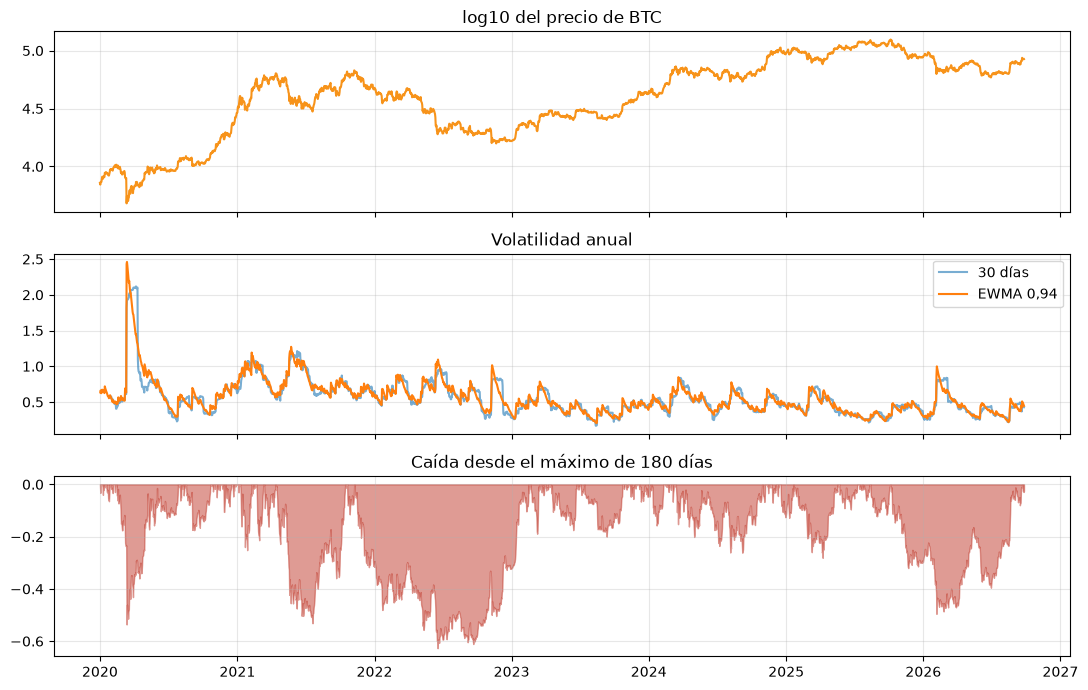

In [8]:
fig, ejes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
ejes[0].plot(np.log10(d["close"]), color=COLORES["BTC"]); ejes[0].set_title("log10 del precio de BTC")
ejes[1].plot(d["vol_30"], label="30 días", alpha=0.6); ejes[1].plot(d["vol_ewma"], label="EWMA 0,94")
ejes[1].set_title("Volatilidad anual"); ejes[1].legend()
ejes[2].fill_between(d.index, d["caida_180"], 0, color="#c0392b", alpha=0.5)
ejes[2].set_title("Caída desde el máximo de 180 días")
plt.tight_layout(); plt.show()

La volatilidad viene **en rachas**: hay meses tranquilos y meses agitados, y un mes agitado suele
seguir a otro. Por eso se puede prever (Unidad 6), mientras que la dirección del precio no.

## 4. La regla de oro: nada del futuro

Una variable que usa datos de mañana "predice" de maravilla en el pasado y falla en el futuro. Es el
error más común, y la IA lo comete a menudo. El ejemplo típico es una media móvil **centrada**
(`rolling(20, center=True)`): para el día t promedia 10 días antes y 10 **después**.

Comparemos cómo se relacionan con el rendimiento de **mañana** dos versiones de la misma variable:

In [9]:
manana = d["r"].shift(-1)                                    # rendimiento del día siguiente
dist_bien = d["close"] / d["close"].rolling(20).mean() - 1
dist_mal = d["close"] / d["close"].rolling(20, center=True).mean() - 1
print(f"Correlación con el rendimiento de mañana, media del pasado: {dist_bien.corr(manana):+.3f}")
print(f"Correlación con el rendimiento de mañana, media centrada:   {dist_mal.corr(manana):+.3f}")

Correlación con el rendimiento de mañana, media del pasado: +0.013
Correlación con el rendimiento de mañana, media centrada:   -0.356


La centrada parece una variable útil, y es un espejismo: con datos reales no existiría, porque mañana
todavía no ha pasado. Tres comprobaciones para cualquier variable:
1. ¿Se podría haber calculado al cierre del día t, con lo que se sabía entonces?
2. ¿Usa `shift(-k)`, `center=True`, `bfill` o estadísticas de toda la muestra? Sospecha.
3. ¿"Predice" demasiado bien? (más de un 55-60 % de aciertos en dirección es casi siempre un error).

## 5. La variable objetivo

Es lo que el modelo intenta predecir, y es la **única** que mira al futuro, a propósito:

| Objetivo | Tipo | Código |
|---|---|---|
| `r_manana`: rendimiento de mañana | regresión | `r.shift(-1)` |
| `sube`: ¿mañana sube? | clasificación | `(r.shift(-1) > 0)` |
| `vol_7`: volatilidad de los próximos 7 días | regresión | desviación de `r` de t+1 a t+7 |

El último día no tiene "mañana": su objetivo queda vacío y se descarta.

In [10]:
d["r_manana"] = d["r"].shift(-1)
d["sube"] = (d["r_manana"] > 0).astype(float).where(d["r_manana"].notna())
d["vol_7"] = d["r"].rolling(7).std().shift(-7) * np.sqrt(ANUAL)
d[["r", "r_manana", "sube", "vol_7"]].tail(9).round(4)

,r,r_manana,sube,vol_7
fecha,,,,
2026-09-18 00:00:00+00:00,0.0568,0.0045,1.0,0.5233
2026-09-19 00:00:00+00:00,0.0045,-0.0009,0.0,0.5234
2026-09-20 00:00:00+00:00,-0.0009,0.0649,1.0,NaN
2026-09-21 00:00:00+00:00,0.0649,-0.0048,0.0,NaN
2026-09-22 00:00:00+00:00,-0.0048,-0.0212,0.0,NaN
2026-09-23 00:00:00+00:00,-0.0212,0.0001,1.0,NaN
2026-09-24 00:00:00+00:00,0.0001,-0.0037,0.0,NaN
2026-09-25 00:00:00+00:00,-0.0037,0.0040,1.0,NaN
2026-09-26 00:00:00+00:00,0.0040,NaN,NaN,NaN


## 6. Caso aplicado: el conjunto de datos listo para modelar

Variables (X) y objetivos (y) en una sola tabla, sin huecos. La división en **entrenamiento** y
**prueba** se hace por fecha, nunca al azar: se entrena con el pasado y se evalúa con el futuro, como
pasaría en la realidad.

In [11]:
variables = ["r", "r_1", "r_2", "dist_sma50", "mom_30", "vol_30", "vol_ewma", "rsi_14", "caida_180", "vol_rel"]
objetivos = ["r_manana", "sube", "vol_7"]
dataset = d[variables + objetivos].dropna()
corte = "2025-01-01"
entreno, prueba = dataset[dataset.index < corte], dataset[dataset.index >= corte]
print(f"{len(dataset)} días: {len(entreno)} para entrenar (hasta 2024) y {len(prueba)} para probar (2025-2026)")
dataset.to_csv("dataset_btc.csv", date_format="%Y-%m-%d")
dataset[variables].corrwith(dataset["r_manana"]).round(3).sort_values()

2405 días: 1778 para entrenar (hasta 2024) y 627 para probar (2025-2026)


r            -0.070
r_2          -0.019
caida_180     0.013
vol_rel       0.015
mom_30        0.021
dist_sma50    0.026
vol_30        0.027
vol_ewma      0.035
rsi_14        0.036
r_1           0.045
dtype: float64

La última tabla adelanta la conclusión de las unidades 4 y 7: ninguna variable pasa de 0,07 de
correlación con el rendimiento de mañana. Una correlación de 0,07 explica un 0,5 % de su variación
(0,07² ≈ 0,005). Con la volatilidad de los próximos días es otra historia:

In [12]:
dataset[variables].corrwith(dataset["vol_7"]).round(3).sort_values()

caida_180    -0.142
rsi_14       -0.084
r            -0.080
mom_30       -0.065
r_1          -0.053
r_2          -0.040
dist_sma50   -0.033
vol_rel       0.183
vol_30        0.366
vol_ewma      0.412
dtype: float64

La volatilidad reciente (`vol_ewma`, `vol_30`) se correlaciona en torno a 0,4 con la de la semana
siguiente. Esa diferencia, casi nada para la dirección y bastante para la volatilidad, es la idea sobre
la que está construido el piloto.

## 7. Así lo usa el piloto

La regla del piloto, para una cartera que fuera **solo BTC**, con sus valores de fábrica:

$$\text{parte en cripto} = \min\left(1,\ \frac{15\,\%}{\text{vol\_ewma}}\right) \times \text{freno}(\text{caida\_180})$$

El freno vale 1 mientras la caída no pase del 10 %; baja en línea recta hasta 0,25 con una caída del
25 %, y no baja de ahí.

Dos diferencias con el piloto real: la caída se mide sobre **tu cuenta** (lo que tienes, que ya
sigue la regla), no sobre el precio de BTC; y la volatilidad es la de **tu mezcla** de monedas. La
Unidad 9 lo reconstruye completo.

26-09-2026: volatilidad prevista 44.6%, caída -2.5% -> en BTC el 34%, en USDT el resto


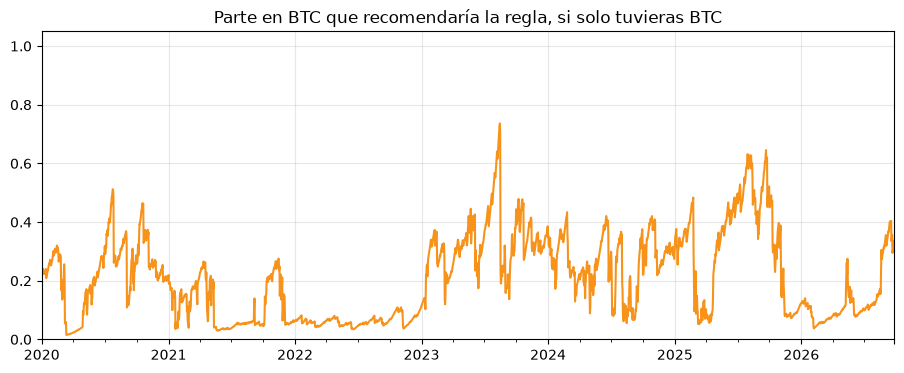

In [13]:
def freno(caida, inicio=0.10, tope=0.25, minimo=0.25):
    c = -caida
    lineal = np.clip(1 - (c - inicio) / (tope - inicio), 0, 1)
    return np.maximum(minimo, lineal)


expo = np.minimum(1, 0.15 / d["vol_ewma"]) * freno(d["caida_180"])
hoy = d.index[-1]
print(f"{hoy:%d-%m-%Y}: volatilidad prevista {d.loc[hoy, 'vol_ewma']:.1%}, caída {d.loc[hoy, 'caida_180']:.1%}"
      f" -> en BTC el {expo.loc[hoy]:.0%}, en USDT el resto")
ax = expo.plot(title="Parte en BTC que recomendaría la regla, si solo tuvieras BTC", color=COLORES["BTC"])
ax.set_ylim(0, 1.05); ax.set_xlabel(""); plt.show()

## Ejercicios

1. **Lambda.** Calcula `vol_ewma` con λ = 0,97 y con λ = 0,80. ¿Cuál reacciona antes al 12-03-2020?
   ¿Cuál es más estable? ¿Qué pasaría con las recomendaciones del piloto con cada una?
2. **ETH.** Repite la sección 7 con ETH. ¿Qué parte en cripto recomendaría hoy? ¿Por qué es menor que
   con BTC?
3. **Otra fuga.** Estandariza `r` con la media y la desviación de **toda** la muestra y con las de los
   últimos 365 días. ¿Cuántos días a más de 4 desviaciones salen con cada una?
4. **Una variable tuya.** Inventa una variable (por ejemplo, el rango `high − low` dividido por el
   cierre) y comprueba las tres preguntas de la sección 4. ¿Se correlaciona con `vol_7`?